In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import pandas as pd
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import ROOT as root
from ROOT import TFile, TTree, TList
from scipy.optimize import curve_fit
import sympy as sp

In [2]:
cGy = 1e2 # cGy -> Gy

In [3]:
dataset="DetRotX0deg/20241011_173036"

In [4]:
filenames = [2, 4, 6, 8, 10, 15, 20, 25, 30, 35]
mean_dose = []
mean_dose1 = []
mean_dose2 = []
dose_grid = []

df10x10 = pd.DataFrame()

for z in filenames:
     print(str(z),"cm data processing ...")
     pathList = glob.glob(dataset+"/0cm"+"/*/2Dmap"+ str(z) +"cm4mm.out")
     print(pathList)
     df10x10 = pd.DataFrame()
     
     for filename in pathList:
        temp_df = pd.read_csv(filename, sep=",", header=None, skiprows=4, 
                               names=["iX", "iY", "iZ", "dose", "dose^2", "entries"])
        df10x10 = df10x10.add(temp_df, fill_value=0)
        
     if not df10x10.empty:
        df10x10 /= len(pathList)
        dose_pivot = df10x10.pivot(index='iX', columns='iY', values='dose') * cGy
        dose_grid.append(dose_pivot)
        mean_dose1.append(np.mean(dose_pivot,1))
        mean_dose2.append(np.mean(dose_pivot,0))


2 cm data processing ...
['DetRotX0deg/20241011_173036/0cm/9/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/11/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/7/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/6/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/1/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/10/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/8/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/4/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/3/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/12/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/2/2Dmap2cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/5/2Dmap2cm4mm.out']
4 cm data processing ...
['DetRotX0deg/20241011_173036/0cm/9/2Dmap4cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/11/2Dmap4cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/7/2Dmap4cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/6/2Dmap4cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/1/2Dmap4cm4mm.out', 'DetRotX0deg/20241011_173036/0cm/10/2Dmap4c

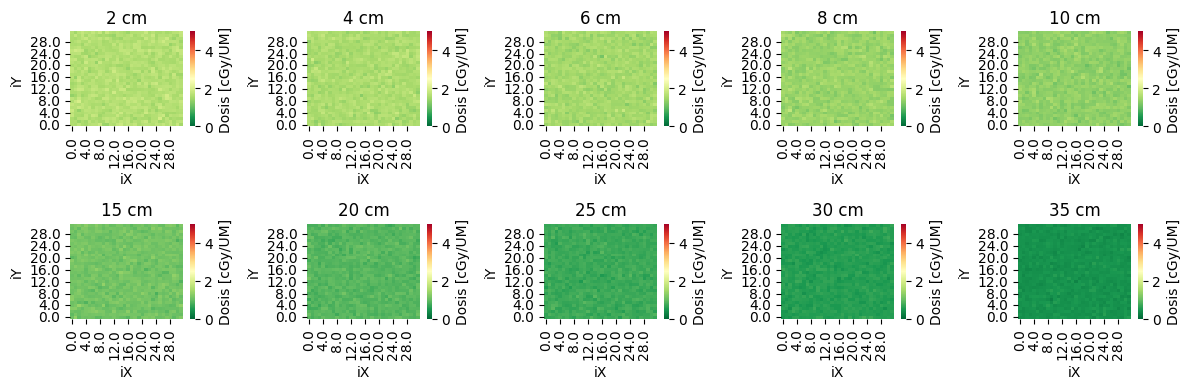

In [5]:
fig=plt.figure(figsize=(12,4))

i = 0
for data in dose_grid:
    ax1=fig.add_subplot(2,5,i+1)
    ax1.set_title(str(filenames[i]) + ' cm')
    cbar_kws = { 'label': 'Dosis [cGy/UM]'}
    ax1 = sns.heatmap(data=data.T, cmap='RdYlGn_r', cbar=True, cbar_kws=cbar_kws, vmin=0, vmax=5)
    ax1.invert_yaxis()
    i=i+1

fig.tight_layout()
plt.show()

In [6]:
nC = 1e9  # nC -> C
nofEvents = 1000e6 
nofEvents = 50e6    
fScaleFactorMU = 1/2.3514811546434146e-13
fSimulatedMU = 1
scale_factor = (1./nofEvents)*fScaleFactorMU*fSimulatedMU

In [7]:
print(scale_factor) # 4252.64

85052.77603652689


In [8]:
SensorReadout1 = np.zeros([32,12,np.size(filenames)])
SensorReadout2 = np.zeros([32,12,np.size(filenames)])
mean_charge1 = []
mean_charge2 = []

k=0
for z in filenames:
     print(str(z),"cm data processing ...")
     pathList = glob.glob(dataset+"/"+ str(z) +"cm"+"/*/BB7Readout.root")
     print(pathList)

     j=0
     for path in pathList:
          print("File",str(j),"is being read ...")
          f = root.TFile(path)
          myTree = f.Get("BB7Hits")
          entries = myTree.GetEntriesFast()

          for entry in myTree:
               stripID = int(entry.StripID)
               if(entry.SensorID==0):
                    SensorReadout1[stripID,j,k] += myTree.GetLeaf('Charge[coulomb]').GetValue()*scale_factor*nC
               if(entry.SensorID==1):
                    SensorReadout2[stripID,j,k] += myTree.GetLeaf('Charge[coulomb]').GetValue()*scale_factor*nC
          j=j+1
     mean_charge1.append(np.mean(SensorReadout1[:,:,k],1))
     mean_charge2.append(np.mean(SensorReadout2[:,:,k],1))
     k=k+1

2 cm data processing ...
['DetRotX0deg/20241011_173036/2cm/9/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/11/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/7/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/6/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/1/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/10/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/8/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/4/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/3/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/12/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/2/BB7Readout.root', 'DetRotX0deg/20241011_173036/2cm/5/BB7Readout.root']
File 0 is being read ...
File 1 is being read ...
File 2 is being read ...
File 3 is being read ...
File 4 is being read ...
File 5 is being read ...
File 6 is being read ...
File 7 is being read ...
File 8 is being read ...
File 9 is being read ...
File 10 is being read ...
File 11 is being read ...
4 cm data processing ...
['DetRot

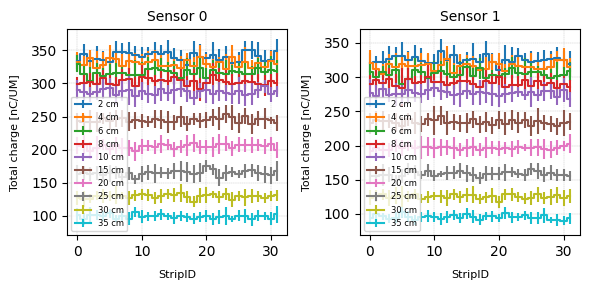

In [9]:
fig=plt.figure(figsize=(6,3))

x=np.linspace(0, 31, 32)

ax1=fig.add_subplot(121)
ax1.set_title('Sensor 0', fontsize=10)
ax1.set_xlabel('StripID', fontsize=8,labelpad=8)
ax1.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax1.set_ylim([0, 200])
ax1.grid(linestyle='--', linewidth=0.25)

k=0
for z in filenames:
    ax1.errorbar(x,np.mean(SensorReadout1[:,:,k],1),yerr=np.std(SensorReadout1[:,:,k],1), ds='steps-mid', label=str(z) + ' cm')
    k=k+1


ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(122)
ax2.set_title('Sensor 1', fontsize=10)
ax2.set_xlabel('StripID', fontsize=8,labelpad=8)
ax2.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax2.set_ylim([0, 200])
ax2.grid(linestyle='--', linewidth=0.25)

k=0
for z in filenames:
    ax2.errorbar(x,np.mean(SensorReadout2[:,:,k],1),yerr=np.std(SensorReadout2[:,:,k],1), ds='steps-mid', label=str(z) + ' cm')
    k=k+1

ax2.legend(loc='best', fontsize="6")

fig.tight_layout()
plt.show()

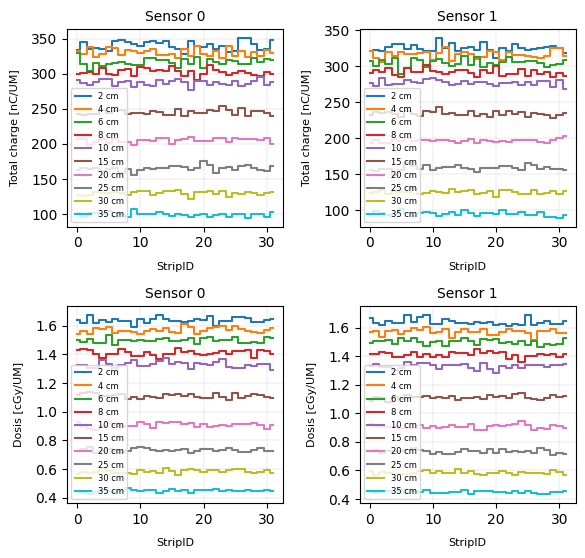

In [10]:
fig=plt.figure(figsize=(6,8))

x=np.linspace(0, 31, 32)

ax1=fig.add_subplot(321)
ax1.set_title('Sensor 0', fontsize=10)
ax1.set_xlabel('StripID', fontsize=8,labelpad=8)
ax1.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax1.set_ylim([0, 200])
ax1.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax1.errorbar(x,np.array(mean_charge1[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1


ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(322)
ax2.set_title('Sensor 1', fontsize=10)
ax2.set_xlabel('StripID', fontsize=8,labelpad=8)
ax2.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax2.set_ylim([0, 200])
ax2.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax2.errorbar(x,np.array(mean_charge2[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1

ax2.legend(loc='best', fontsize="6")

ax3=fig.add_subplot(323)
ax3.set_title('Sensor 0', fontsize=10)
ax3.set_xlabel('StripID', fontsize=8,labelpad=8)
ax3.set_ylabel('Dosis [cGy/UM]', fontsize=8,labelpad=8)
#ax3.set_ylim([0, 200])
ax3.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax3.errorbar(x,np.array(mean_dose1[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1


ax3.legend(loc='best', fontsize="6")

ax4=fig.add_subplot(324)
ax4.set_title('Sensor 1', fontsize=10)
ax4.set_xlabel('StripID', fontsize=8,labelpad=8)
ax4.set_ylabel('Dosis [cGy/UM]', fontsize=8,labelpad=8)
#ax4.set_ylim([0, 200])
ax4.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax4.errorbar(x,np.array(mean_dose2[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1

ax4.legend(loc='best', fontsize="6")

fig.tight_layout()
plt.show()

In [11]:
charge1 = np.array(mean_charge1) # nC
print("Carga promedio por strip (Sensor1):",charge1,"nC/UM")

charge2 = np.array(mean_charge2) # nC
print("Carga promedio por strip (Sensor2):",charge2,"nC/UM")

dose1 = np.array(mean_dose1) # cGy
print("Dosis absorbda en agua por posición de strip (Sensor1):",dose1,"cGy/UM")

dose2 = np.array(mean_dose2) # cGy
print("Dosis absorbda en agua por posición de strip (Sensor2):",dose2,"cGy/UM")

Carga promedio por strip (Sensor1): [[333.32885343 344.88955154 334.49860959 337.30910361 334.85403242
  332.18980221 347.01061579 347.69113807 345.12805849 342.31209666
  339.15249703 344.70233646 346.99528206 344.07507741 346.73625518
  338.07721202 334.82303564 327.3687756  346.5147206  340.07374292
  338.1979832  342.2369315  335.48830482 340.01571252 331.32296082
  332.0523664  350.74283718 350.37568835 341.94931981 334.41576223
  335.59481993 348.27503274]
 [332.79803349 328.02407439 337.58823479 323.9320173  327.89089132
  337.99788951 336.72318307 326.30799535 334.11634733 332.28536352
  329.68180847 332.27727365 335.84105336 326.26212815 326.34571023
  328.10533647 322.82102626 335.31330289 325.89837925 339.26040209
  328.61989832 325.23888676 332.13959483 322.12564718 339.76043533
  325.41876373 332.73369381 323.83777667 330.53469473 324.81475113
  333.78212917 329.15724784]
 [329.96470637 313.85618283 304.24352409 315.21384451 310.50501544
  313.55207457 315.86141454 315.983

In [12]:
def lineal0(x, a):
    return a * x

In [13]:
def pow0(x, a, b):
    return a * x ** b

In [14]:
strips=np.linspace(0, 31, 32)

In [15]:
popt1=[]
pcov1=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(lineal0, charge1[:,stripID], dose1[:,stripID])
        popt1.append(popt_tmp)
        pcov1.append(pcov_tmp)
        print("Optimal parameters (a):", popt1[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a): [0.00465745]
Optimal parameters (a): [0.00468156]
Optimal parameters (a): [0.00473063]
Optimal parameters (a): [0.00467246]
Optimal parameters (a): [0.00466542]
Optimal parameters (a): [0.00469316]
Optimal parameters (a): [0.00461568]
Optimal parameters (a): [0.00465571]
Optimal parameters (a): [0.00464762]
Optimal parameters (a): [0.00467218]
Optimal parameters (a): [0.00464933]
Optimal parameters (a): [0.00461923]
Optimal parameters (a): [0.00462557]
Optimal parameters (a): [0.00464158]
Optimal parameters (a): [0.0047057]
Optimal parameters (a): [0.00466138]
Optimal parameters (a): [0.00469957]
Optimal parameters (a): [0.00472679]
Optimal parameters (a): [0.00469813]
Optimal parameters (a): [0.0046297]
Optimal parameters (a): [0.00468016]
Optimal parameters (a): [0.00466102]
Optimal parameters (a): [0.00467242]
Optimal parameters (a): [0.00470658]
Optimal parameters (a): [0.00466302]
Optimal parameters (a): [0.00474267]
Optimal parameters (a): [0.00463595]
Opt

In [16]:
popt2=[]
pcov2=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(lineal0, charge2[:,stripID], dose2[:,stripID])
        popt2.append(popt_tmp)
        pcov2.append(pcov_tmp)
        print("Optimal parameters (a):", popt2[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a): [0.00488618]
Optimal parameters (a): [0.00489471]
Optimal parameters (a): [0.00485608]
Optimal parameters (a): [0.00485935]
Optimal parameters (a): [0.00483613]
Optimal parameters (a): [0.00488135]
Optimal parameters (a): [0.0048776]
Optimal parameters (a): [0.00487426]
Optimal parameters (a): [0.00490092]
Optimal parameters (a): [0.00487405]
Optimal parameters (a): [0.00484583]
Optimal parameters (a): [0.00477076]
Optimal parameters (a): [0.00483507]
Optimal parameters (a): [0.00487373]
Optimal parameters (a): [0.00487826]
Optimal parameters (a): [0.00485195]
Optimal parameters (a): [0.00484901]
Optimal parameters (a): [0.00488893]
Optimal parameters (a): [0.00487363]
Optimal parameters (a): [0.00487574]
Optimal parameters (a): [0.0048656]
Optimal parameters (a): [0.00489433]
Optimal parameters (a): [0.00481148]
Optimal parameters (a): [0.00485105]
Optimal parameters (a): [0.00484558]
Optimal parameters (a): [0.00489312]
Optimal parameters (a): [0.00480179]
Opt

In [17]:
popt3=[]
pcov3=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(pow0, charge1[:,stripID], dose1[:,stripID])
        popt3.append(popt_tmp)
        pcov3.append(pcov_tmp)
        print("Optimal parameters (a, b):", popt3[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a, b): [0.00309631 1.07229666]
Optimal parameters (a, b): [0.00325504 1.06442   ]
Optimal parameters (a, b): [0.00288503 1.08778104]
Optimal parameters (a, b): [0.00233913 1.12281535]
Optimal parameters (a, b): [0.00292147 1.08299331]
Optimal parameters (a, b): [0.00276978 1.09349504]
Optimal parameters (a, b): [0.00304149 1.0738549 ]
Optimal parameters (a, b): [0.00296479 1.07990949]
Optimal parameters (a, b): [0.00336953 1.05692713]
Optimal parameters (a, b): [0.00346763 1.05291632]
Optimal parameters (a, b): [0.00328751 1.06143119]
Optimal parameters (a, b): [0.00338414 1.05506128]
Optimal parameters (a, b): [0.00322517 1.06379269]
Optimal parameters (a, b): [0.00237188 1.1188463 ]
Optimal parameters (a, b): [0.00300464 1.07946227]
Optimal parameters (a, b): [0.00323347 1.06481758]
Optimal parameters (a, b): [0.00216763 1.13734125]
Optimal parameters (a, b): [0.00283638 1.09061864]
Optimal parameters (a, b): [0.00318732 1.06877603]
Optimal parameters (a, b): [0.0

In [18]:
popt4=[]
pcov4=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(pow0, charge2[:,stripID], dose2[:,stripID])
        popt4.append(popt_tmp)
        pcov4.append(pcov_tmp)
        print("Optimal parameters (a, b):", popt4[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a, b): [0.00348599 1.06027937]
Optimal parameters (a, b): [0.00259535 1.11339477]
Optimal parameters (a, b): [0.00280898 1.09781693]
Optimal parameters (a, b): [0.00321011 1.07396346]
Optimal parameters (a, b): [0.00349941 1.0577148 ]
Optimal parameters (a, b): [0.00294686 1.09024599]
Optimal parameters (a, b): [0.00217185 1.14434742]
Optimal parameters (a, b): [0.00295631 1.08914587]
Optimal parameters (a, b): [0.00326961 1.07224222]
Optimal parameters (a, b): [0.00254744 1.1157117 ]
Optimal parameters (a, b): [0.00272485 1.10280123]
Optimal parameters (a, b): [0.00343274 1.05856034]
Optimal parameters (a, b): [0.002771   1.09926976]
Optimal parameters (a, b): [0.00252521 1.11748952]
Optimal parameters (a, b): [0.00298356 1.0878252 ]
Optimal parameters (a, b): [0.00294331 1.08907495]
Optimal parameters (a, b): [0.00283752 1.09566773]
Optimal parameters (a, b): [0.00345203 1.06218541]
Optimal parameters (a, b): [0.00257206 1.11404672]
Optimal parameters (a, b): [0.0

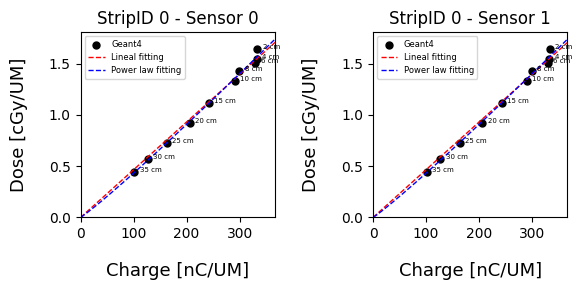

In [19]:
charge1_max=int(np.max(charge1[:])*1.1)
x1=np.linspace(0, charge1_max, charge1_max)

fig=plt.figure(figsize=(6,3))

ax1=fig.add_subplot(121)
ax1.set_title("StripID 0 - Sensor 0")
ax1.set_xlim([0, np.max(charge1[:,0])*1.1])
ax1.set_ylim([0, np.max(dose1[:,0])*1.1])
ax1.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax1.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax1.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax1.annotate(str(label)+' cm', (charge1[:,0][i] + 10, dose1[:,0][i]),fontsize=5)
ax1.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax1.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(122)
ax2.set_title("StripID 0 - Sensor 1")
ax2.set_xlim([0, np.max(charge1[:,0])*1.1])
ax2.set_ylim([0, np.max(dose1[:,0])*1.1])
ax2.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax2.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax2.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax2.annotate(str(label)+' cm', (charge1[:,0][i] + 10, dose1[:,0][i]),fontsize=5)
ax2.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax2.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax2.legend(loc='best', fontsize="6")

fig.tight_layout()

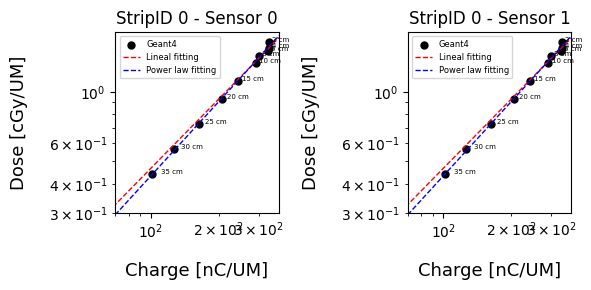

In [24]:
charge1_max=int(np.max(charge1[:])*1.1)
x1=np.linspace(0, charge1_max, charge1_max)

fig=plt.figure(figsize=(6,3))

ax1=fig.add_subplot(121)
ax1.set_title("StripID 0 - Sensor 0")
ax1.loglog()
ax1.set_xlim([70, np.max(charge1[:,0])*1.1])
ax1.set_ylim([0.3, np.max(dose1[:,0])*1.1])
ax1.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax1.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax1.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax1.annotate(str(label)+' cm', (charge1[:,0][i] + 10, dose1[:,0][i]),fontsize=5)
ax1.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax1.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(122)
ax2.loglog()
ax2.set_title("StripID 0 - Sensor 1")
ax2.set_xlim([70, np.max(charge1[:,0])*1.1])
ax2.set_ylim([0.3, np.max(dose1[:,0])*1.1])
ax2.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax2.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax2.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax2.annotate(str(label)+' cm', (charge1[:,0][i] + 10, dose1[:,0][i]),fontsize=5)
ax2.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax2.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax2.legend(loc='best', fontsize="6")

fig.tight_layout()

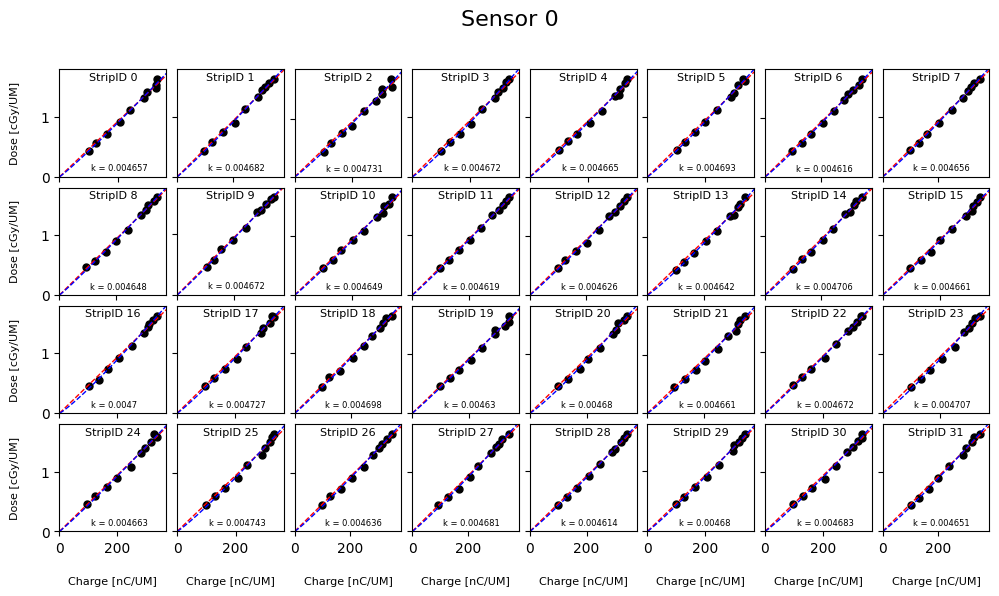

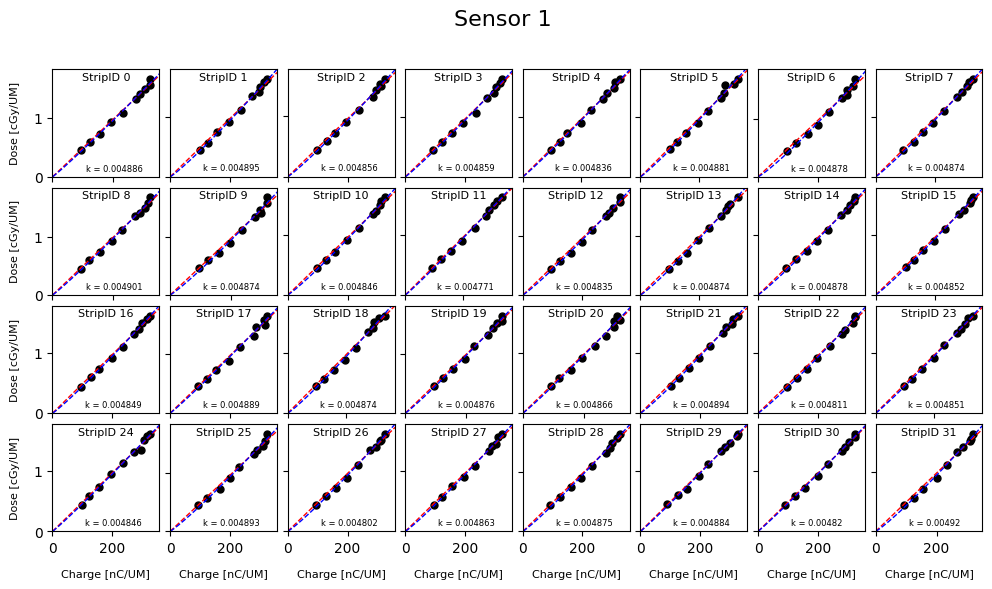

In [20]:
charge1_max=int(np.max(charge1[:])*1.1)
x1=np.linspace(0, charge1_max, charge1_max)

fig1=plt.figure(figsize=(12,6))
fig1.suptitle('Sensor 0', fontsize=16)

for stripID, value in enumerate(strips):
    ax1=fig1.add_subplot(4,8,stripID+1)
    ax1.set_xlim([0, np.max(charge1[:,stripID])*1.1])
    ax1.set_ylim([0, np.max(dose1[:,stripID])*1.1])
    ax1.set_title('StripID '+ str(stripID), fontsize=8, y=1.0, pad=-8)
    if(stripID>=24):
        ax1.set_xlabel('Charge [nC/UM]', fontsize=8,labelpad=15)
    else:
        ax1.set_xticklabels([])
    if(stripID%8==0):
        ax1.set_ylabel('Dose [cGy/UM]', fontsize=8,labelpad=15)
    else:
        ax1.set_yticklabels([])
    ax1.scatter(charge1[:,stripID],dose1[:,stripID],s=25, facecolors='black', edgecolors='black', label="Geant4")
    #for i, label in enumerate(filenames):
    #    ax1.annotate(str(label)+' cm', (charge1[:,stripID][i] + 10, dose[i]),fontsize=5)
    ax1.annotate("k = " + str(np.round(popt1[stripID][0],6)), (110, 0.1),fontsize=6)
    ax1.plot(x1, lineal0(x1, *popt1[stripID]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
    ax1.plot(x1, pow0(x1, *popt3[stripID]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

#ax1.legend(loc='best', fontsize="6")

fig1.subplots_adjust(wspace=0.1, hspace=0.1) #tight_layout()

charge2_max=int(np.max(charge2[:])*1.1)
x2=np.linspace(0, charge2_max, charge2_max)

fig2=plt.figure(figsize=(12,6))
fig2.suptitle('Sensor 1', fontsize=16)

for stripID, value in enumerate(strips):
    ax2=fig2.add_subplot(4,8,stripID+1)
    ax2.set_xlim([0, np.max(charge2[:,stripID])*1.1])
    ax2.set_ylim([0, np.max(dose2[:,stripID])*1.1])
    ax2.set_title('StripID '+ str(stripID), fontsize=8, y=1.0, pad=-8)
    if(stripID>=24):
        ax2.set_xlabel('Charge [nC/UM]', fontsize=8,labelpad=10)
    else:
        ax2.set_xticklabels([])
    if(stripID%8==0):
        ax2.set_ylabel('Dose [cGy/UM]', fontsize=8,labelpad=10)
    else:
        ax2.set_yticklabels([])
    ax2.scatter(charge2[:,stripID],dose2[:,stripID],s=25, facecolors='black', edgecolors='black', label="Geant4")
    #for i, label in enumerate(filenames):
    #    ax2.annotate(str(label)+' cm', (charge2[:,stripID][i] + 10, dose[i]),fontsize=5)
    ax2.annotate("k = " + str(np.round(popt2[stripID][0],6)), (110, 0.1),fontsize=6)
    ax2.plot(x2, lineal0(x2, *popt2[stripID]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
    ax2.plot(x2, pow0(x2, *popt4[stripID]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

#ax2.legend(loc='best', fontsize="6")

fig2.subplots_adjust(wspace=0.1, hspace=0.1) #tight_layout()


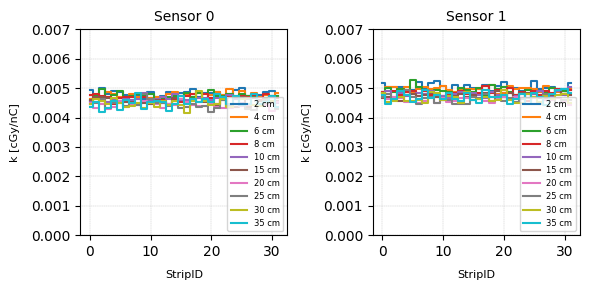

In [21]:
fig=plt.figure(figsize=(6,3))

x=np.linspace(0, 31, 32)

ax3=fig.add_subplot(121)
ax3.set_title('Sensor 0', fontsize=10)
ax3.set_xlabel('StripID', fontsize=8,labelpad=8)
ax3.set_ylabel('k [cGy/nC]', fontsize=8,labelpad=8)
ax3.set_ylim([0, 0.007])
ax3.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax3.errorbar(x,np.array(mean_dose1[i]/mean_charge1[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1


ax3.legend(loc='best', fontsize="6")

ax4=fig.add_subplot(122)
ax4.set_title('Sensor 1', fontsize=10)
ax4.set_xlabel('StripID', fontsize=8,labelpad=8)
ax4.set_ylabel('k [cGy/nC]', fontsize=8,labelpad=8)
ax4.set_ylim([0, 0.007])
ax4.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax4.errorbar(x,np.array(mean_dose2[i]/mean_charge2[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1

ax4.legend(loc='best', fontsize="6")

fig.tight_layout()
plt.show()